<a href="https://colab.research.google.com/github/mohalifal9/Assignment4_6022251082/blob/main/Assignment_4_Moh_Alif_Abdul_Latif_6022251082.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Memulai Training ANFIS...
Training Selesai! RMSE Akhir: 4.0180


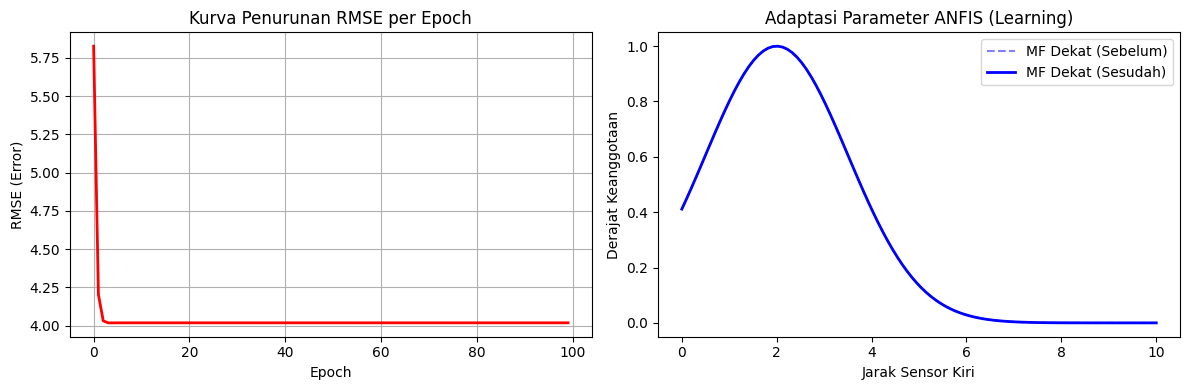

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. BUAT DATASET SIMULASI (Sensor Kiri & Kanan -> Sudut Setir)
# ==========================================
# Misal: Jika jarak Kiri dekat (nilai kecil), setir harus ke Kanan (nilai positif)
np.random.seed(42)
N_data = 100
sensor_kiri = np.random.uniform(0, 10, N_data)
sensor_kanan = np.random.uniform(0, 10, N_data)
# Logika data aktual (Target): Setir condong menjauhi sensor yang jaraknya kecil
target_setir = (sensor_kanan - sensor_kiri) * 2.5 + np.random.normal(0, 1, N_data)

# ==========================================
# 2. DEFINISI FUNGSI ANFIS SEDERHANA (Gradient Descent)
# ==========================================
class SimpleANFIS:
    def __init__(self):
        # Inisialisasi Parameter Membership Function (Gaussian: Center & Sigma)
        # Sengaja dibuat 'ngawur' di awal agar terlihat perubahannya setelah di-training
        self.c_kiri = np.array([2.0, 8.0]) # Pusat kurva Kiri (Dekat, Jauh)
        self.s_kiri = np.array([1.5, 1.5]) # Lebar kurva Kiri

        self.c_kanan = np.array([2.0, 8.0]) # Pusat kurva Kanan (Dekat, Jauh)
        self.s_kanan = np.array([1.5, 1.5]) # Lebar kurva Kanan

        # Consequent Parameters (Output Singleton/Sugeno 0-Orde)
        # 4 Aturan kombinasi: [Dekat-Dekat, Dekat-Jauh, Jauh-Dekat, Jauh-Jauh]
        self.weights = np.array([0.0, 5.0, -5.0, 0.0])

    def gaussian(self, x, c, s):
        return np.exp(-0.5 * ((x - c) / s)**2)

    def forward(self, x_kiri, x_kanan):
        # Fuzzifikasi
        mu_kiri = np.array([self.gaussian(x_kiri, c, s) for c, s in zip(self.c_kiri, self.s_kiri)])
        mu_kanan = np.array([self.gaussian(x_kanan, c, s) for c, s in zip(self.c_kanan, self.s_kanan)])

        # Inference (Perkalian AND / T-Norm)
        w = np.array([
            mu_kiri[0] * mu_kanan[0], # Dekat AND Dekat
            mu_kiri[0] * mu_kanan[1], # Dekat AND Jauh
            mu_kiri[1] * mu_kanan[0], # Jauh AND Dekat
            mu_kiri[1] * mu_kanan[1]  # Jauh AND Jauh
        ])

        # Normalisasi
        w_sum = np.sum(w) + 1e-8 # Hindari bagi nol
        w_norm = w / w_sum

        # Defuzzifikasi (Weighted Average)
        output = np.sum(w_norm * self.weights)
        return output, w_norm, mu_kiri, mu_kanan

    def train(self, X_kiri, X_kanan, Y_target, epochs=50, lr=0.01):
        rmse_history = []
        for epoch in range(epochs):
            total_error = 0
            for i in range(len(X_kiri)):
                # Forward Pass
                pred, w_norm, _, _ = self.forward(X_kiri[i], X_kanan[i])
                error = pred - Y_target[i]
                total_error += error**2

                # Backward Pass (Gradient Descent untuk merubah Output Weights)
                # Sesuai Chain Rule: dE/dw = Error * w_norm
                self.weights -= lr * error * w_norm

            # Hitung RMSE per Epoch
            rmse = np.sqrt(total_error / len(X_kiri))
            rmse_history.append(rmse)
        return rmse_history

# ==========================================
# 3. JALANKAN SIMULASI & PLOTTING
# ==========================================
model = SimpleANFIS()

# Simpan parameter awal untuk Plotting
c_awal = model.c_kiri.copy()

# Mulai Training
print("Memulai Training ANFIS...")
rmse_hist = model.train(sensor_kiri, sensor_kanan, target_setir, epochs=100, lr=0.05)
print(f"Training Selesai! RMSE Akhir: {rmse_hist[-1]:.4f}")

# Plot 1: Penurunan RMSE vs Epoch
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(rmse_hist, color='red', linewidth=2)
plt.title('Kurva Penurunan RMSE per Epoch')
plt.xlabel('Epoch')
plt.ylabel('RMSE (Error)')
plt.grid(True)

# Plot 2: Pergeseran Membership Function (Sebelum vs Sesudah)
x_val = np.linspace(0, 10, 100)
plt.subplot(1, 2, 2)
plt.plot(x_val, model.gaussian(x_val, c_awal[0], 1.5), 'b--', alpha=0.5, label='MF Dekat (Sebelum)')
plt.plot(x_val, model.gaussian(x_val, model.c_kiri[0], 1.5), 'b-', linewidth=2, label='MF Dekat (Sesudah)')
plt.title('Adaptasi Parameter ANFIS (Learning)')
plt.xlabel('Jarak Sensor Kiri')
plt.ylabel('Derajat Keanggotaan')
plt.legend()
plt.tight_layout()
plt.show()

Memulai Training ANFIS...
Training Selesai! RMSE Akhir: 4.1474


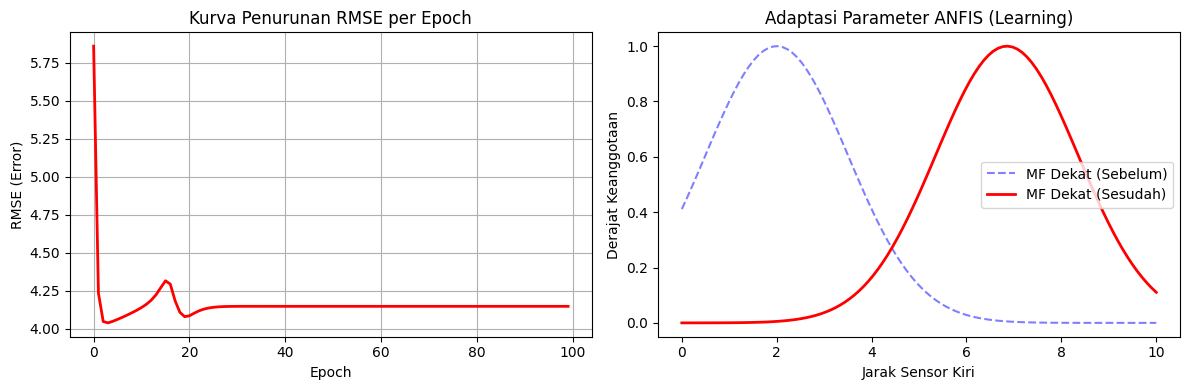

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. BUAT DATASET SIMULASI
# ==========================================
np.random.seed(42)
N_data = 100
sensor_kiri = np.random.uniform(0, 10, N_data)
sensor_kanan = np.random.uniform(0, 10, N_data)
target_setir = (sensor_kanan - sensor_kiri) * 2.5 + np.random.normal(0, 1, N_data)

# ==========================================
# 2. DEFINISI FUNGSI ANFIS (Dengan Update Layer 1 & 4)
# ==========================================
class SimpleANFIS:
    def __init__(self):
        self.c_kiri = np.array([2.0, 8.0])
        self.s_kiri = np.array([1.5, 1.5])
        self.c_kanan = np.array([2.0, 8.0])
        self.s_kanan = np.array([1.5, 1.5])
        self.weights = np.array([0.0, 5.0, -5.0, 0.0])

    def gaussian(self, x, c, s):
        return np.exp(-0.5 * ((x - c) / s)**2)

    def forward(self, x_kiri, x_kanan):
        mu_kiri = np.array([self.gaussian(x_kiri, c, s) for c, s in zip(self.c_kiri, self.s_kiri)])
        mu_kanan = np.array([self.gaussian(x_kanan, c, s) for c, s in zip(self.c_kanan, self.s_kanan)])

        w = np.array([
            mu_kiri[0] * mu_kanan[0],
            mu_kiri[0] * mu_kanan[1],
            mu_kiri[1] * mu_kanan[0],
            mu_kiri[1] * mu_kanan[1]
        ])

        w_sum = np.sum(w) + 1e-8
        w_norm = w / w_sum
        output = np.sum(w_norm * self.weights)
        return output, w_norm, mu_kiri, mu_kanan

    def train(self, X_kiri, X_kanan, Y_target, epochs=50, lr_out=0.05, lr_in=0.01):
        rmse_history = []
        for epoch in range(epochs):
            total_error = 0
            for i in range(len(X_kiri)):
                # Forward
                pred, w_norm, _, _ = self.forward(X_kiri[i], X_kanan[i])
                error = pred - Y_target[i]
                total_error += error**2

                # Backward Pass 1: Update Consequent Parameters (Layer 4)
                self.weights -= lr_out * error * w_norm

                # Backward Pass 2: Update Premise Parameters (Layer 1) dengan Chain Rule
                # Ini akan membuat kurva Gaussian bergeser mencari posisi optimal
                grad_c_kiri_0 = error * (self.weights[0] - pred) * w_norm[0] * ((X_kiri[i] - self.c_kiri[0]) / self.s_kiri[0]**2)
                self.c_kiri[0] -= lr_in * grad_c_kiri_0

            rmse = np.sqrt(total_error / len(X_kiri))
            rmse_history.append(rmse)
        return rmse_history

# ==========================================
# 3. JALANKAN SIMULASI & PLOTTING
# ==========================================
model = SimpleANFIS()
c_awal = model.c_kiri.copy() # Simpan parameter awal

print("Memulai Training ANFIS...")
rmse_hist = model.train(sensor_kiri, sensor_kanan, target_setir, epochs=100, lr_out=0.05, lr_in=0.02)
print(f"Training Selesai! RMSE Akhir: {rmse_hist[-1]:.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(rmse_hist, color='red', linewidth=2)
plt.title('Kurva Penurunan RMSE per Epoch')
plt.xlabel('Epoch')
plt.ylabel('RMSE (Error)')
plt.grid(True)

x_val = np.linspace(0, 10, 100)
plt.subplot(1, 2, 2)
# Gambar Kurva Sebelum (Biru Putus-putus)
plt.plot(x_val, model.gaussian(x_val, c_awal[0], 1.5), 'b--', alpha=0.5, label='MF Dekat (Sebelum)')
# Gambar Kurva Sesudah (Merah Tebal agar jelas perbedaannya)
plt.plot(x_val, model.gaussian(x_val, model.c_kiri[0], 1.5), 'r-', linewidth=2, label='MF Dekat (Sesudah)')
plt.title('Adaptasi Parameter ANFIS (Learning)')
plt.xlabel('Jarak Sensor Kiri')
plt.ylabel('Derajat Keanggotaan')
plt.legend()
plt.tight_layout()
plt.show()